# VAE

First off, I'll disable RDKit's logging messages

In [1]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [2]:
import random
import numpy as np
import torch
import pandas as pd

# set seeds 
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ensure deterministic behavior
torch.backends.mps.deterministic = True
torch.use_deterministic_algorithms(True)

## Import Libraries and Dataset

In [3]:
import rdkit
from rdkit import Chem
print(torch.__version__)

# sanity check rdkit
print(Chem.MolFromSmiles("CCO"))

2.11.0


Import ADME class from the Therapeutic Data Commons (TDC) library - specifically the CYP2D6 Veith dataset. The Veith dataset contains molecules labelled as either inhibiting or not inhibiting this enzyme (0 or 1).
TDC's default splitting strategy is a scaffold split. 

In [4]:
from tdc.single_pred import ADME

data = ADME(name='CYP2D6_Veith')
split = data.get_split()
train_df = split['train']
valid_df = split['valid']
test_df  = split['test']

print(f"Train = {len(train_df)}, Valid = {len(valid_df)}, Test = {len(test_df)}")
train_df.head()

Found local copy...
Loading...
Done!


Train = 9191, Valid = 1313, Test = 2626


,Drug_ID,Drug,Y
0,644675.0,CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1,0
1,644890.0,COc1ccccc1C(c1nnnn1C(C)(C)C)N1CCN(Cc2ccncc2)CC1,1
2,645164.0,CCC(c1nnnn1CC1CCCO1)N(CCN1CCOCC1)Cc1cc2cc(C)cc...,0
3,6602688.0,Br.N=c1n(CCN2CCOCC2)c2ccccc2n1CC(=O)c1ccc(Cl)c...,1
4,645448.0,CCC(C)(C)NC(=O)c1ccc2c(c1)N(CC(=O)OC)C(=O)C(C)...,0


The following cell is optional for augmenting SMILES

In [5]:
#def augment_smiles(smi, n=10):
    #mol = Chem.MolFromSmiles(smi)
    #if mol is None:
     #   return [smi]
    #variants = set()
    #variants.add(Chem.MolToSmiles(mol))  # canonical
    #for _ in range(n):
     #   variants.add(Chem.MolToSmiles(mol, doRandom=True))
    #return list(variants)

Also, I filtered out '.' from the SMILES strings because it represents multiple disconnected molecules written as one string. **It's important to note** that 1% of the disconnected fragments consists of actual second molecules. The majority being salts with halogens, then counterions, and solvents with water. 

In [6]:
def keep_largest_fragment(smi):
    if '.' not in smi:
        return smi
    frags = smi.split('.')
    mols = [(Chem.MolFromSmiles(f), f) for f in frags]
    mols = [(m, f) for m, f in mols if m is not None]
    if not mols:
        return None
    return max(mols, key=lambda x: x[0].GetNumHeavyAtoms())[1]

# Observe the disconnected molecules before filtering
for df in [train_df, valid_df, test_df]:
    disconnected = df[df['Drug'].str.contains('\.', regex=True)]
    print(f"Disconnected molecules: {len(disconnected)}")
    print(disconnected['Drug'].head(20).tolist())

for df in [train_df, valid_df, test_df]:
    df['Drug'] = df['Drug'].apply(keep_largest_fragment)
    df.dropna(subset=['Drug'], inplace=True)
    # MAX_LENGTH = 100 includes <sos> and <eos>, so SMILES can be at most 98 chars
    df.drop(df[df['Drug'].str.len() > 98].index, inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"After filtering: Train = {len(train_df)}, Valid = {len(valid_df)}, Test = {len(test_df)}")

#augmented_rows = []
#for _, row in train_df.iterrows():
 #   for smi in augment_smiles(row['Drug'], n=3):
  #      augmented_rows.append({'Drug': smi, 'Y': row['Y']})

#train_df = pd.DataFrame(augmented_rows).reset_index(drop=True)
#print(f"Original train size: {len(split['train'])}")
#print(f"Augmented train size: {len(train_df)}")

Disconnected molecules: 388
['Br.N=c1n(CCN2CCOCC2)c2ccccc2n1CC(=O)c1ccc(Cl)c(Cl)c1', 'CN(C)CCNC(=O)C(C(=O)c1ccc(F)cc1)n1ccccc1=O.Cl', 'Cl.O=C(CN1CCN(c2ncccn2)CC1)NCCC1=CCCCC1', 'CCOC(=O)C1Cc2c([nH]c3ccccc23)CN1.Cl', 'Cl.O=C(CN1CCN(C2CCCCC2)CC1)NCCC1=CCCCC1', 'CCC(c1nnnn1CCOC)N1CCN(C(=O)c2ccco2)CC1.Cl', 'I.OCCNC1=NCCN1', 'COc1cc2c(cc1OC)/C(=C/C(=O)N1CCOCC1)NC(C)(C)C2.Cl', 'CC1=CC=CN2CC(O)CN=C12.Cl', 'Cc1ccc2c(c1)[C@@H]1CN(C)CC[C@@H]1N2S(=O)(=O)c1ccc(F)cc1.Cl', 'CN(C)CC(O)COc1cccc(OCC(O)CN(C)C)c1.Cl', 'CN(C)CC(O)COc1ccc(C(C)(C)c2ccc(OCC(O)CN(C)C)cc2)cc1.Cl', 'COc1ccc(C(=O)OC(C)CN2CCN(C)CC2)cc1OC.Cl', 'C[n+]1cccc(CNC(=O)/C=N/O)c1.[I-]', 'Cl.OC1(c2ccc(F)cc2)CCNC1', 'Cl.NCCCCCc1nnc(SCc2ccccc2Cl)o1', 'Cn1c[n+](C)cc1/C=N/O.[I-]', 'Cl.c1ccc2c(c1)oc1c(NCCCn3ccnc3)ncnc12', 'Br.CC1(C(=O)CSc2nc3ccccc3s2)CCC(=O)O1', 'Br.CCCCCCN1Cc2ccccc2C1']
Disconnected molecules: 61
['CCCn1c(N)[n+](CC(=O)c2ccco2)c2ccccc21.[Br-]', 'Br.CC[C@H]1CN2CC[C@@H]1C[C@H]2[C@@H](O)c1ccnc2ccc(OC)cc12.O', 'CC(C)(C)NCC[C@@H](O)

### Check class imbalance

In [7]:
full_df = pd.concat([split['train'], valid_df, test_df])
print(full_df['Y'].value_counts())
print(full_df['Y'].value_counts(normalize=True))

Y
0    10359
1     2492
Name: count, dtype: int64
Y
0    0.806085
1    0.193915
Name: proportion, dtype: float64


## Building the character vocabulary
We start off by building the character vocabulary, since a VAE encodes smiles strings into a latent vector. a neural network cant take raw text - only numbers, so we convert each character in a smiles string to an integer.

`<pad>` - used to make all SMILES the same length in a batch (token = 0)

`<sos>` - start of sequence, tells the decoder to begin generating (token = 1)

`<eos>` - end of sequence, tells the decoder to stop (token = 2)

In [8]:
train_smiles = train_df['Drug'].tolist()
valid_smiles = valid_df['Drug'].tolist()
test_smiles  = test_df['Drug'].tolist()
df = pd.concat([train_df, valid_df, test_df])
all_smiles = df['Drug'].tolist()
vocab = sorted(set(''.join(all_smiles)))
vocab = ['<pad>', '<sos>', '<eos>'] + vocab

char2idx = {ch: idx for idx, ch in enumerate(vocab)}
idx2char = {idx: ch for ch, idx in char2idx.items()}

print(f"Vocabulary size: {len(vocab)}")
print(f"Characters: {vocab}")

Vocabulary size: 41
Characters: ['<pad>', '<sos>', '<eos>', '#', '(', ')', '+', '-', '/', '1', '2', '3', '4', '5', '6', '7', '=', '@', 'A', 'B', 'C', 'F', 'H', 'I', 'N', 'O', 'P', 'S', '[', '\\', ']', 'b', 'c', 'e', 'g', 'i', 'l', 'n', 'o', 'r', 's']


Next step is to check the distribution of SMILES lengths to configure padding

Max length: 98
Mean length: 43.6
95th percentile: 72


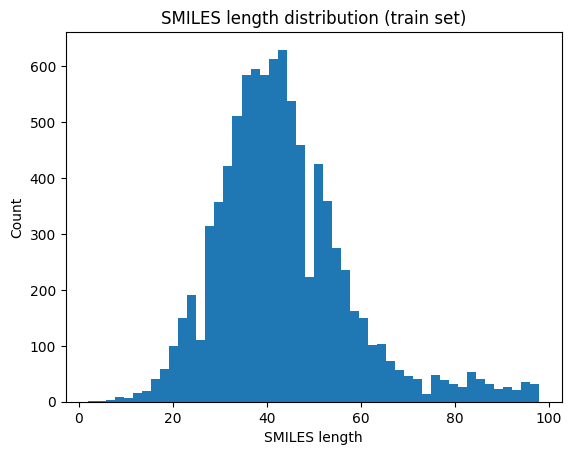

In [9]:
import matplotlib.pyplot as plt

lengths = [len(s) for s in train_smiles]
print(f"Max length: {max(lengths)}")
print(f"Mean length: {sum(lengths)/len(lengths):.1f}")
print(f"95th percentile: {sorted(lengths)[int(0.95*len(lengths))]}")

plt.hist(lengths, bins=50)
plt.xlabel("SMILES length")
plt.ylabel("Count")
plt.title("SMILES length distribution (train set)")
plt.show()

## Tokenization and Encoding of SMILES 

In [10]:
MAX_LENGTH = 100

def encode_smiles(smiles, char2idx, max_length):
    """
    Convert a SMILES string to a fixed-length integer sequence.
    
    Wraps the sequence with <sos> and <eos> tokens, truncates sequences
    longer than max_length, and pads shorter sequences with <pad> tokens.
    
    Args:
        smiles (str): SMILES string of a molecule.
        char2idx (dict): mapping from character to integer index.
        max_length (int): fixed length for all output sequences.
    
    Returns:
        list[int]: integer-encoded sequence of length max_length.
    """
    tokens = ['<sos>'] + list(smiles) + ['<eos>']
    tokens = tokens[:max_length]
    tokens += ['<pad>'] * (max_length - len(tokens))
    return [char2idx[t] for t in tokens]


Example:

In [11]:
smiles_list = train_smiles[:5]
example = smiles_list[0]
encoded = encode_smiles(example, char2idx, MAX_LENGTH)
print(f"SMILES: {example}")
print(f"Encoded: {encoded}")
print(f"Length: {len(encoded)}")

SMILES: CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1
Encoded: [1, 20, 20, 4, 16, 25, 5, 24, 4, 32, 9, 32, 32, 32, 10, 38, 32, 4, 16, 25, 5, 40, 32, 10, 32, 9, 5, 27, 4, 16, 25, 5, 4, 16, 25, 5, 32, 9, 32, 32, 32, 40, 9, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 100


## Data encoding

Tokenise SMILES strings to fixed-length integer sequences (MAX_LENGTH) and pair with binary CYP2D6 inhibition labels. Positive rates are printed to verify class imbalance is consistent across splits. Basically it encodes every SMILES string in all three splits into integer tensors that PyTorch can work with and extracts the CYP2D6 inhibition layers into separate float tensors, one per split, to use in the loss function. 

In [12]:
encoded_train = torch.tensor([encode_smiles(s, char2idx, MAX_LENGTH) for s in train_smiles], dtype=torch.long)
encoded_valid = torch.tensor([encode_smiles(s, char2idx, MAX_LENGTH) for s in valid_smiles], dtype=torch.long)
encoded_test  = torch.tensor([encode_smiles(s, char2idx, MAX_LENGTH) for s in test_smiles],  dtype=torch.long)

train_labels = torch.tensor(train_df['Y'].tolist(), dtype=torch.float)
valid_labels = torch.tensor(valid_df['Y'].tolist(), dtype=torch.float)
test_labels  = torch.tensor(test_df['Y'].tolist(),  dtype=torch.float)

print(f"encoded_train: {encoded_train.shape}  pos rate: {train_labels.mean():.3f}")
print(f"encoded_valid: {encoded_valid.shape}  pos rate: {valid_labels.mean():.3f}")
print(f"encoded_test:  {encoded_test.shape}   pos rate: {test_labels.mean():.3f}")

encoded_train: torch.Size([8990, 100])  pos rate: 0.195
encoded_valid: torch.Size([1291, 100])  pos rate: 0.201
encoded_test:  torch.Size([2570, 100])   pos rate: 0.187


## Build the pytorch dataset and dataloader

In [13]:
from torch.utils.data import Dataset, DataLoader

class SMILESDataset(Dataset):
    def __init__(self, encoded_data, labels):
        self.data = encoded_data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

train_dataset = SMILESDataset(encoded_train, train_labels)
valid_dataset = SMILESDataset(encoded_valid, valid_labels)
test_dataset  = SMILESDataset(encoded_test,  test_labels)

g = torch.Generator()
g.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, generator=g)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Valid: {len(valid_dataset)} samples, {len(valid_loader)} batches")
print(f"Test:  {len(test_dataset)} samples, {len(test_loader)} batches")

Train: 8990 samples, 141 batches
Valid: 1291 samples, 21 batches
Test:  2570 samples, 41 batches


## VAE Model


## Encoder

In [14]:
import torch.nn as nn
import torch.nn.functional as F


class Encoder(nn.Module):
    """
    Encodes a tokenised SMILES sequence into a latent distribution (mu, log_var)
    using two 1D convolutional layers followed by a fully-connected projection.

    Args:
        vocab_size (int): number of unique tokens in the vocabulary.
        seq_len (int): fixed length of the input sequence (MAX_LENGTH).
        hidden_dim (int): width of the fully-connected layer after flattening.
        latent_dim (int): dimension of the latent space.
    """
    def __init__(self, vocab_size, seq_len, hidden_dim, latent_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.conv = nn.Sequential(
            nn.Conv1d(vocab_size, 128, kernel_size=9, stride=1, padding=0),
            nn.Tanh(),
            nn.Conv1d(128, 256, kernel_size=9, stride=1, padding=0),
            nn.Tanh(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, vocab_size, seq_len)
            flat_size = self.conv(dummy).view(1, -1).shape[1]
        self.fc = nn.Linear(flat_size, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        """
        Args:
            x (Tensor): tokenised SMILES batch of shape (batch_size, seq_len).

        Returns:
            mu (Tensor): mean of the latent distribution, shape (batch_size, latent_dim).
            log_var (Tensor): log variance of the latent distribution, shape (batch_size, latent_dim).
        """
        embedded = F.one_hot(x, num_classes=self.vocab_size).float()  # (batch, seq_len, vocab_size)
        x_conv = embedded.permute(0, 2, 1)                            # (batch, vocab_size, seq_len)
        h = self.conv(x_conv)                                         # (batch, 256, seq_len)
        h = h.view(h.size(0), -1)                                     # (batch, 256 * seq_len)
        h = F.relu(self.fc(h))   # (batch, hidden_dim)                                     
        return self.fc_mu(h), self.fc_logvar(h)

## Reparameterisation

The encoder outputs `mu` and `log_var`, which define a probability distribution in latent space.
We sample a latent vector `z` from this distribution using the reparameterisation trick.
This allows gradients to flow through the sampling step during backpropagation.

In [15]:
def reparameterise(mu, log_var):
    """
    Sample a latent vector z using the reparameterisation trick.
    
    Instead of sampling z directly from N(mu, std), we sample epsilon from N(0,1)
    and compute z = mu + epsilon * std. This keeps the sampling step differentiable.
    
    Args:
        mu (Tensor): mean of the latent distribution, shape (batch_size, latent_dim).
        log_var (Tensor): log variance of the latent distribution, shape (batch_size, latent_dim).
    
    Returns:
        z (Tensor): sampled latent vector, shape (batch_size, latent_dim).
    """
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std

## Decoder

The decoder takes the latent vector z and reconstructs the SMILES sequence token by token.
It uses a GRU that generates one token at a time, conditioned on z.

In [16]:
class Decoder(nn.Module):
    """
    Decodes a latent vector z into a SMILES sequence autoregressively.
    
    z is both used to initialise the GRU hidden state via fc_z and repeated 
    across all timesteps and concatenated with the one-hot token input at each 
    step, so the GRU sees z at initialisation and at every decoding timestep.
    Hard teacher forcing is used during training.
    
    Args:
        vocab_size (int): number of unique tokens in the vocabulary.
        hidden_dim (int): hidden dimension of the GRU.
        latent_dim (int): dimension of the latent space.
        n_layers (int): number of GRU layers.
    """
    def __init__(self, vocab_size, hidden_dim, latent_dim, n_layers):
        super().__init__()
        self.vocab_size = vocab_size
        self.n_layers = n_layers
        self.hidden_dim = hidden_dim
        self.fc_z = nn.Linear(latent_dim, hidden_dim * n_layers)
        self.gru = nn.GRU(vocab_size + latent_dim, hidden_dim, n_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, z, x):
        """
        Args:
            z (Tensor): latent vector, shape (batch_size, latent_dim).
            x (Tensor): target sequence, shape (batch_size, seq_len).
        
        Returns:
            logits (Tensor): predicted token scores, shape (batch_size, seq_len-1, vocab_size).
        """
        hidden = self.fc_z(z)
        hidden = hidden.view(-1, self.n_layers, self.hidden_dim).permute(1, 0, 2).contiguous()

        seq_len = x.size(1) - 1
        x_onehot = F.one_hot(x[:, :-1], num_classes=self.vocab_size).float()  # (batch, seq_len-1, vocab_size)
        z_repeated = z.unsqueeze(1).expand(-1, seq_len, -1)                   # (batch, seq_len-1, latent_dim)
        gru_input = torch.cat([x_onehot, z_repeated], dim=-1)                 # (batch, seq_len-1, vocab_size + latent_dim)

        output, _ = self.gru(gru_input, hidden)
        logits = self.fc_out(output)
        return logits

In [17]:
class PropertyPredictor(nn.Module):
    """
    Predicts CYP inhibition from the latent mean mu.

    A two-layer MLP that takes mu directly rather than a sampled z, ensuring
    a deterministic and stable input during training, consistent with inference.
    Outputs a raw logit intended for use with BCEWithLogitsLoss.

    Args:
        latent_dim (int): dimension of the latent space, used as input size.
        hidden_size (int): number of hidden units in the intermediate layer. Default 64.
        dropout (float): dropout probability applied after the hidden layer. Default 0.5.
    """
    def __init__(self, latent_dim, hidden_size=64, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, mu):
        return self.net(mu).squeeze(-1)


class VAE(nn.Module):
    """
    Variational Autoencoder for SMILES strings.

    Combines the Encoder (convolutional), reparameterisation trick, and Decoder (GRU) into
    a single model. The encoder compresses a SMILES sequence into a latent distribution
    via two Conv1d layers followed by fully-connected projections to mu and log_var;
    a latent vector z is sampled via reparameterisation; the decoder reconstructs the
    sequence autoregressively from z using teacher forcing. A property predictor head
    operates on mu directly to predict CYP inhibition.

    Args:
        vocab_size (int): number of unique tokens in the vocabulary.
        seq_len (int): fixed input sequence length passed to the MLP encoder.
        hidden_dim (int): hidden dimension for both encoder and decoder.
        latent_dim (int): dimension of the latent space.
        n_layers (int): number of GRU layers in the decoder.
    """
    def __init__(self, vocab_size, seq_len, hidden_dim, latent_dim, n_layers):
        super().__init__()
        self.encoder = Encoder(vocab_size, seq_len, hidden_dim, latent_dim)
        self.decoder = Decoder(vocab_size, hidden_dim, latent_dim, n_layers)
        self.predictor = PropertyPredictor(latent_dim)

    def forward(self, x):
        """
        Args:
            x (Tensor): tokenised SMILES batch, shape (batch_size, seq_len).

        Returns:
            logits (Tensor): predicted token scores, shape (batch_size, seq_len-1, vocab_size).
            mu (Tensor): mean of latent distribution, shape (batch_size, latent_dim).
            log_var (Tensor): log variance of latent distribution, shape (batch_size, latent_dim).
            prop_logit (Tensor): property prediction logit, shape (batch_size,).
        """
        mu, log_var = self.encoder(x)
        z = reparameterise(mu, log_var)
        logits = self.decoder(z, x)
        prop_logit = self.predictor(mu)
        return logits, mu, log_var, prop_logit

Architecture Verification:

In [18]:
VOCAB_SIZE = len(vocab)
HIDDEN_DIM = 512
LATENT_DIM = 128
N_LAYERS = 2

model = VAE(VOCAB_SIZE, MAX_LENGTH, HIDDEN_DIM, LATENT_DIM, N_LAYERS)
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv1d(41, 128, kernel_size=(9,), stride=(1,))
      (1): Tanh()
      (2): Conv1d(128, 256, kernel_size=(9,), stride=(1,))
      (3): Tanh()
    )
    (fc): Linear(in_features=21504, out_features=512, bias=True)
    (fc_mu): Linear(in_features=512, out_features=128, bias=True)
    (fc_logvar): Linear(in_features=512, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (fc_z): Linear(in_features=128, out_features=1024, bias=True)
    (gru): GRU(169, 512, num_layers=2, batch_first=True)
    (fc_out): Linear(in_features=512, out_features=41, bias=True)
  )
  (predictor): PropertyPredictor(
    (net): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.5, inplace=False)
      (3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)
Total parameters: 14,270,890


In [19]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")

Using device: mps


## Loss Function

The VAE loss function is as follows:

$$\mathcal{L} = \mathcal{L}_{\text{recon}} + \beta \cdot \mathcal{L}_{\text{KL}} + \gamma \cdot \mathcal{L}_{\text{prop}}$$

where:

- $\mathcal{L}_{\text{recon}}$: reconstruction loss, how well the decoder reconstructs the input SMILES
- $\mathcal{L}_{\text{KL}}$: KL divergence, how close the latent distribution is to a standard normal $\mathcal{N}(0, I)$
- $\mathcal{L}_{\text{prop}}$: property prediction loss for CYP inhibition
- $\beta$ (beta): annealing weight on the KL term, ramped from 0 to $\beta_{\max}$ over training
- $\gamma$ (gamma): fixed weight on the property prediction term

In [20]:
def vae_loss(logits, targets, mu, log_var, beta, prop_logit=None, labels=None, gamma=0.0, kl_free_bits=0.5):
    """
    Compute the VAE loss: reconstruction loss + beta * KL divergence + gamma * property loss.

    Args:
        logits (Tensor): predicted token scores, shape (batch_size, seq_len, vocab_size).
        targets (Tensor): true token indices, shape (batch_size, seq_len).
        mu (Tensor): mean of latent distribution, shape (batch_size, latent_dim).
        log_var (Tensor): log variance of latent distribution, shape (batch_size, latent_dim).
        beta (float): weight on the KL term.
        prop_logit (Tensor, optional): property prediction logits, shape (batch_size,).
        labels (Tensor, optional): binary property labels, shape (batch_size,).
        gamma (float): weight on the property prediction loss.
        kl_free_bits (float): minimum value for the KL divergence term.

    Returns:
        loss (Tensor): total VAE loss.
        recon_loss (Tensor): reconstruction loss component.
        kl_loss (Tensor): KL divergence component.
        prop_loss (Tensor): property prediction loss component (zero if not used).
    """

    recon_loss = nn.CrossEntropyLoss(ignore_index=0, reduction='sum')(
    logits.view(-1, logits.size(-1)),
    targets.reshape(-1)
    ) / (targets != 0).sum()
    kl_per_dim = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp())
    kl_per_dim = torch.clamp(kl_per_dim, min=kl_free_bits)
    kl_loss = torch.mean(torch.sum(kl_per_dim, dim=-1))
    
    prop_loss = torch.tensor(0.0, device=logits.device)
    if prop_logit is not None and labels is not None and gamma > 0:
        pos_weight = torch.tensor(
            (train_labels == 0).sum().item() / (train_labels == 1).sum().item(),
            device=logits.device
        )
        prop_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)(prop_logit, labels)
    loss = recon_loss + beta * kl_loss + gamma * prop_loss
    return loss, recon_loss, kl_loss, prop_loss

## Evaluation


In [21]:
def evaluate(model, dataset, vocab_size, device, idx2char, n_samples=500):
    """
    Measure reconstruction accuracy and validity on a random subset of the dataset.

    Encodes n_samples real molecules to mu (no noise), decodes with teacher forcing
    and hard argmax, then reports exact sequence match rate and RDKit validity rate.
    """
    model.eval()
    indices = torch.randperm(len(dataset))[:n_samples]
    batch = torch.stack([dataset[i][0] for i in indices]).to(device)

    with torch.no_grad():
        mu, _ = model.encoder(batch)
        logits = model.decoder(mu, batch)       # (n_samples, seq_len-1, vocab_size)
        pred_tokens = logits.argmax(dim=-1)     # (n_samples, seq_len-1)

    targets = batch[:, 1:]                      # (n_samples, seq_len-1)
    exact_acc = (pred_tokens == targets).all(dim=1).float().mean().item()
    # exclude padding tokens from token-level accuracy
    mask = targets != 0
    token_acc = (pred_tokens[mask] == targets[mask]).float().mean().item()

    valid_count = 0
    for seq in pred_tokens:
        chars = [idx2char[idx.item()] for idx in seq]
        smiles = ''
        for ch in chars:
            if ch == '<eos>':
                break
            if ch not in ['<pad>', '<sos>']:
                smiles += ch
        if smiles and Chem.MolFromSmiles(smiles) is not None:
            valid_count += 1
    validity = valid_count / n_samples

    return exact_acc, token_acc, validity

## Training loop

Each training run is logged to a local MLflow experiment called `mol-vae`.  
Run `mlflow ui` in the terminal to open the tracking UI at http://localhost:5000

In [22]:
import mlflow
import torch.optim as optim
from pathlib import Path
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import roc_auc_score

EPOCHS = 50
BETA_MAX = 0.008
ANNEAL_EPOCHS = 25 # number of epochs over which to linearly increase beta from 0 to BETA_MAX
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
KL_FREE_BITS = 0.5
GAMMA = 0.05

CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

mlflow.set_tracking_uri("file:///Users/elenipsaromatis/Documents/mol-vae/notebooks/mlruns")
mlflow.set_experiment("mol-vae")

with mlflow.start_run() as run:
    run_id = run.info.run_id
    mlflow.set_tag("mlflow.runName", f"vae_{run_id[:8]}")
    model_path = CHECKPOINT_DIR / f"vae_{run_id[:8]}.pth"
    writer = SummaryWriter(log_dir=f"../runs/{run_id[:8]}")

    mlflow.log_params({
        "vocab_size": VOCAB_SIZE,
        "max_length": MAX_LENGTH,
        "hidden_dim": HIDDEN_DIM,
        "latent_dim": LATENT_DIM,
        "n_layers": N_LAYERS,
        "epochs": EPOCHS,
        "anneal_epochs": ANNEAL_EPOCHS,
        "beta_max": BETA_MAX,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "kl_free_bits": KL_FREE_BITS,
        "gamma": GAMMA,
        "pos_weight": (train_labels == 0).sum().item() / (train_labels == 1).sum().item(),
        "scheduler": "CosineAnnealingLR",
    })

    model = VAE(VOCAB_SIZE, MAX_LENGTH, HIDDEN_DIM, LATENT_DIM, N_LAYERS)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

    def evaluate_loss(model, loader, beta, gamma):
        model.eval()
        total_recon, total_kl, total_prop, n = 0.0, 0.0, 0.0, 0
        with torch.no_grad():
            for batch, labels in loader:
                batch  = batch.to(device)
                labels = labels.to(device)
                logits, mu, log_var, prop_logit = model(batch)
                _, recon, kl, prop = vae_loss(logits, batch[:, 1:], mu, log_var, beta,
                                              prop_logit=prop_logit, labels=labels, gamma=gamma, kl_free_bits=KL_FREE_BITS)
                total_recon += recon.item()
                total_kl    += kl.item()
                total_prop  += prop.item()
                n += 1
        return total_recon / n, total_kl / n, total_prop / n

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        total_recon = 0
        total_kl = 0
        total_prop = 0
        total_grad_norm = 0

        beta = min(BETA_MAX, BETA_MAX * epoch / ANNEAL_EPOCHS)

        for batch, labels in train_loader:
            batch  = batch.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            logits, mu, log_var, prop_logit = model(batch)
            loss, recon_loss, kl_loss, prop_loss = vae_loss(
                logits, batch[:, 1:], mu, log_var, beta,
                prop_logit=prop_logit, labels=labels, gamma=GAMMA, kl_free_bits=KL_FREE_BITS
            )

            loss.backward()

            total_grad_norm += torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0).item()
            optimizer.step()
            total_loss  += loss.item()
            total_recon += recon_loss.item()
            total_kl    += kl_loss.item()
            total_prop  += prop_loss.item()

        n_batches = len(train_loader)
        avg_loss   = total_loss  / n_batches
        train_prop = total_prop  / n_batches

        scheduler.step()

        valid_recon, valid_kl, valid_prop = evaluate_loss(model, valid_loader, beta, GAMMA)

        exact_acc, token_acc, validity = evaluate(model, train_dataset, VOCAB_SIZE, device, idx2char)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1:>2}/{EPOCHS}, beta: {beta:.4f}, "
            f"Loss: {avg_loss:.4f}  Recon: {total_recon/n_batches:.4f}  "
            f"KL: {total_kl/n_batches:.4f}  Prop: {train_prop:.4f}  "
            f"Grad: {total_grad_norm/n_batches:.4f}  LR: {current_lr:.1e}")
        print(f"         Recon acc: {exact_acc:.3f}  Token acc: {token_acc:.3f}  Validity: {validity:.3f}  "
            f"Valid recon: {valid_recon:.4f}  Valid KL: {valid_kl:.4f}  Valid prop: {valid_prop:.4f}")
        

        metrics = {
            "train_loss":   avg_loss,
            "recon_loss":   total_recon / n_batches,
            "kl_loss":      total_kl / n_batches,
            "train_prop":   train_prop,
            "valid_recon":  valid_recon,
            "valid_kl":     valid_kl,
            "valid_prop":   valid_prop,
            "grad_norm":    total_grad_norm / n_batches,
            "beta":         beta,
            "learning_rate": current_lr,
            "recon_acc":    exact_acc,
            "token_acc":    token_acc,
            "validity":     validity,
        }
        mlflow.log_metrics(metrics, step=epoch + 1)
        for name, value in metrics.items():
            writer.add_scalar(name, value, epoch + 1)

    def evaluate_test(model, loader, vocab_size, idx2char, device):
        model.eval()
        all_logits, all_targets, all_prop_logits, all_labels = [], [], [], []
        with torch.no_grad():
            for batch, labels in loader:
                batch  = batch.to(device)
                labels = labels.to(device)
                mu, _ = model.encoder(batch)
                logits = model.decoder(mu, batch)
                prop_logit = model.predictor(mu)
                all_logits.append(logits)
                all_targets.append(batch[:, 1:])
                all_prop_logits.append(prop_logit.cpu())
                all_labels.append(labels.cpu())

        all_logits  = torch.cat(all_logits,  dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        pred_tokens = all_logits.argmax(dim=-1)
        test_recon_acc = (pred_tokens == all_targets).all(dim=1).float().mean().item()

        valid_count = 0
        for seq in pred_tokens:
            chars = [idx2char[idx.item()] for idx in seq]
            smiles = ''
            for ch in chars:
                if ch == '<eos>':
                    break
                if ch not in ['<pad>', '<sos>']:
                    smiles += ch
            if smiles and Chem.MolFromSmiles(smiles) is not None:
                valid_count += 1
        test_validity = valid_count / len(pred_tokens)

        all_prop_logits = torch.cat(all_prop_logits).numpy()
        all_labels      = torch.cat(all_labels).numpy()
        test_auroc = roc_auc_score(all_labels, all_prop_logits)

        return test_recon_acc, test_validity, test_auroc

    test_recon_acc, test_validity, test_auroc = evaluate_test(model, test_loader, VOCAB_SIZE, idx2char, device)
    print(f"\nTest  Recon acc: {test_recon_acc:.3f}  Validity: {test_validity:.3f}  AUROC: {test_auroc:.3f}")
    mlflow.log_metrics({
        "test_recon_acc": test_recon_acc,
        "test_validity":  test_validity,
        "test_auroc":     test_auroc,
    })

    torch.save(model.state_dict(), model_path)
    mlflow.set_tag("checkpoint", str(model_path.resolve()))
    writer.close()
    print(f"\n Model saved as {model_path}")
    print(f"Run ID: {run_id}")


Epoch  1/50, beta: 0.0000, Loss: 2.2204  Recon: 2.1646  KL: 607.1335  Prop: 1.1170  Grad: 2.1468  LR: 1.0e-03
         Recon acc: 0.000  Token acc: 0.535  Validity: 0.004  Valid recon: 1.4879  Valid KL: 470.5825  Valid prop: 1.0735
Epoch  2/50, beta: 0.0003, Loss: 1.2408  Recon: 1.1471  KL: 136.1872  Prop: 1.0015  Grad: 1.4338  LR: 1.0e-03
         Recon acc: 0.000  Token acc: 0.714  Validity: 0.010  Valid recon: 0.8792  Valid KL: 123.8816  Valid prop: 0.9585
Epoch  3/50, beta: 0.0006, Loss: 0.8843  Recon: 0.7702  KL: 106.4271  Prop: 0.9193  Grad: 1.1617  LR: 9.9e-04
         Recon acc: 0.000  Token acc: 0.787  Validity: 0.022  Valid recon: 0.6874  Valid KL: 106.5506  Valid prop: 0.9183
Epoch  4/50, beta: 0.0010, Loss: 0.7534  Recon: 0.6167  KL: 98.4998  Prop: 0.8434  Grad: 1.1545  LR: 9.8e-04
         Recon acc: 0.000  Token acc: 0.824  Validity: 0.042  Valid recon: 0.5813  Valid KL: 100.0871  Valid prop: 0.8820
Epoch  5/50, beta: 0.0013, Loss: 0.6858  Recon: 0.5272  KL: 93.4311  Prop

In [23]:
client = mlflow.tracking.MlflowClient()
artifacts = client.list_artifacts(run_id)
for a in artifacts:
    print(a.path)

## Sampling evaluation

Validity rate that shows how useful the latent space is for generation. It samples z from the standard normal prior, meaning it generates molecules from scratch rather than encoding any real molecule. At each step it samples from the full probability distribution using multinomial sampling rather than always picking the most likely token.

In [24]:
from rdkit import Chem

def sample_molecules(model, num_samples, latent_dim, device, idx2char, max_length=100):
    """
    Sample molecules from the VAE using ancestral sampling.

    At each decoding step we draw the next token from the model's exact
    conditional distribution p(x_t | x_{1:t-1}, z) via multinomial sampling.
    z is concatenated to the one-hot input at every step to match the decoder
    architecture.
    """
    model.eval()
    sos_idx = next(idx for idx, ch in idx2char.items() if ch == '<sos>')

    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim).to(device)

        hidden = model.decoder.fc_z(z)
        hidden = hidden.view(-1, model.decoder.n_layers, model.decoder.hidden_dim).permute(1, 0, 2).contiguous()

        input_token = torch.full((num_samples, 1), sos_idx, dtype=torch.long).to(device)

        generated = []
        for _ in range(max_length):
            input_onehot = F.one_hot(input_token, num_classes=len(idx2char)).float()  # (batch, 1, vocab_size)
            z_step = z.unsqueeze(1)                                                    # (batch, 1, latent_dim)
            gru_input = torch.cat([input_onehot, z_step], dim=-1)                     # (batch, 1, vocab_size + latent_dim)
            output, hidden = model.decoder.gru(gru_input, hidden)
            logits = model.decoder.fc_out(output.squeeze(1))                          # (batch, vocab_size)

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)                      # (batch, 1)
            generated.append(next_token)
            input_token = next_token

        generated = torch.cat(generated, dim=1)  # (batch, max_length)

        valid_smiles = []
        for seq in generated:
            chars = [idx2char[idx.item()] for idx in seq]
            smiles = ''
            for ch in chars:
                if ch == '<eos>':
                    break
                if ch not in ['<pad>', '<sos>']:
                    smiles += ch
            valid_smiles.append(smiles)

    valid = [s for s in valid_smiles if Chem.MolFromSmiles(s) is not None]
    print(f"Sampled: {num_samples}")
    print(f"Valid SMILES: {len(valid)}")
    print(f"Validity rate: {len(valid)/num_samples*100:.1f}%")
    print("\nExamples:")
    for s in valid[:5]:
        print(s)

    return valid

valid_mols = sample_molecules(model, 100, LATENT_DIM, device, idx2char)

Sampled: 100
Valid SMILES: 35
Validity rate: 35.0%

Examples:
COc1ccccc1C[C@@H]1C(OCC[C@@H]2C1)N(Cc1cccnc1)N(C)CC2
C[C@H](CNC(=O)c1cccc(C)c1)c1ccc(S(N)(C)C)cc1
COc1cc(=O)n(-c2ccc(CNc3ccccc3O)c2=O)c(Cl)c1
CNCCCN(CC(C)C)CNC1CCCCC1
O=C(C)/C=C(\C#N)C(=O)c1ccc(Cc2ccccc2)cc1


## Encode → Decode Inspection

Encode a SMILES string through the VAE and compare the original to the reconstruction.
- `Exact`: the decoded SMILES string is character-for-character identical to the original input
- `Valid`: the decoded string differs from the original but is still a chemically valid molecule (RDKit can parse it without returning None) 
- `Invalid`: the decoded string is neither exact nor a parseable SMILES string — RDKit returns None, meaning the output is chemically meaningless

Summary — exact: 93/100  valid: 5/100  invalid: 2/100

Valid (non-exact) reconstructions:
  Original : CCOC(=O)CC(=O)CSc1nc(-c2cccnc2)cc(C)c1C#N
  Decoded  : CCOC(=O)CC(=O)CSc1nc(-c2ccccc2)nc(C)c1C#N
  Diff     :                            ^   ^         

  Original : CCOC(=O)c1c(N2C(=O)Nc3cc(Cl)c(Cl)cc3N2O)sc2c1CCCCC2
  Decoded  : CCOC(=O)c1c(N2C(=O)Nc3cc(Cl)c(Cl)cc3N2C)sc2c1CCCCC2
  Diff     :                                       ^            

  Original : COC(=O)C1=C(NC(=O)c2cccc(OC)c2)CCS1
  Decoded  : COC(=O)C1=C(NC(=O)c2ccccc2)C(=O)CC1
  Diff     :                         ^^^^^^^^ ^ 

  Original : CCOC(=O)C(=O)NCc1ccc(/C=C2\C(=O)C(C(=O)OC)=C(C)N2c2ccccc2)o1
  Decoded  : CCOC(=O)C(=O)NCc1ccc(/C=C2\C(=O)C(C(=O)OC)C2c2ccco2)cc1
  Diff     :                                           ^^^^^^^^ ^  ^

  Original : COC(=O)COc1ccc(/C=C2/SC(=O)N(CC(=O)N3CCCC3)C2=O)cc1Br
  Decoded  : COC(=O)COc1ccc(/C=C2/SC(=O)N(CC(=O)N3CCCC3)C2=O)cc1
  Diff     :                                           

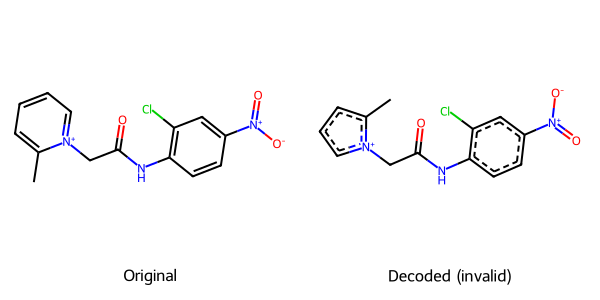


  Original : Nc1ncnc2c1cnn2-c1ccccc1
  Decoded  : Nc1ncnc2c1ncn2c1ccccc12
  Diff     :           ^^  ^^^    ^^


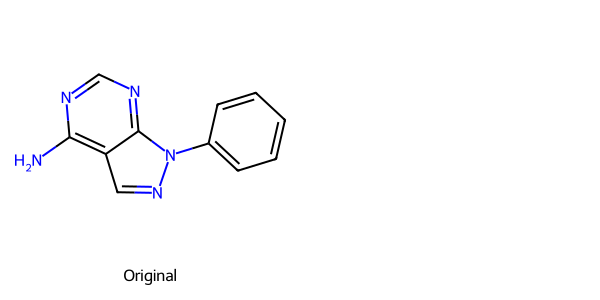

In [25]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def inspect_dataset_reconstructions(model, dataset, smiles_list, char2idx, idx2char, device, n_samples=100):
    """
    Encode n_samples molecules from the dataset, decode them, and print
    the original vs reconstruction side by side with a character-level diff.
    """
    model.eval()
    indices = torch.randperm(len(dataset))[:n_samples]
    batch = torch.stack([dataset[i][0] for i in indices]).to(device)
    with torch.no_grad():
        mu, log_var = model.encoder(batch)
        hidden = model.decoder.fc_z(mu)
        hidden = hidden.view(-1, model.decoder.n_layers, model.decoder.hidden_dim).permute(1, 0, 2).contiguous()
        sos_idx = char2idx['<sos>']
        input_token = torch.full((n_samples, 1), sos_idx, dtype=torch.long).to(device)
        generated = []
        for _ in range(MAX_LENGTH):
            x_onehot = F.one_hot(input_token, num_classes=len(char2idx)).float()
            z_step = mu.unsqueeze(1)
            gru_input = torch.cat([x_onehot, z_step], dim=-1)
            output, hidden = model.decoder.gru(gru_input, hidden)
            logits = model.decoder.fc_out(output.squeeze(1))
            next_token = logits.argmax(dim=-1, keepdim=True)
            generated.append(next_token)
            input_token = next_token
        generated = torch.cat(generated, dim=1)
    exact, valid, invalid = 0, 0, 0
    valid_cases = []
    invalid_cases = []
    for i, idx in enumerate(indices):
        original = smiles_list[idx.item()]
        decoded_chars = []
        for tok in generated[i]:
            ch = idx2char[tok.item()]
            if ch == '<eos>':
                break
            if ch not in ('<pad>', '<sos>'):
                decoded_chars.append(ch)
        decoded = ''.join(decoded_chars)
        is_exact = decoded == original
        is_valid = Chem.MolFromSmiles(decoded) is not None
        if is_exact:
            exact += 1
        elif is_valid:
            valid += 1
            valid_cases.append((original, decoded))
        else:
            invalid += 1
            invalid_cases.append((original, decoded))
    print(f"Summary — exact: {exact}/{n_samples}  valid: {valid}/{n_samples}  invalid: {invalid}/{n_samples}")

    print("\nValid (non-exact) reconstructions:")
    for original, decoded in valid_cases:
        diff = ''
        for a, b in zip(original, decoded):
            diff += ' ' if a == b else '^'
        if len(decoded) > len(original):
            diff += '^' * (len(decoded) - len(original))
        print(f"  Original : {original}")
        print(f"  Decoded  : {decoded}")
        print(f"  Diff     : {diff}")
        print()

    print("\nInvalid reconstructions:")
    for original, decoded in invalid_cases:
        diff = ''
        for a, b in zip(original, decoded):
            diff += ' ' if a == b else '^'
        if len(decoded) > len(original):
            diff += '^' * (len(decoded) - len(original))
        print(f"  Original : {original}")
        print(f"  Decoded  : {decoded}")
        print(f"  Diff     : {diff}")
        mol_orig = Chem.MolFromSmiles(original)
        mol_dec = Chem.MolFromSmiles(decoded, sanitize=False)
        imgs = []
        legends = []
        if mol_orig:
            imgs.append(mol_orig)
            legends.append("Original")
        if mol_dec:
            imgs.append(mol_dec)
            legends.append("Decoded (invalid)")
        if imgs:
            display(Draw.MolsToGridImage(imgs, molsPerRow=2, subImgSize=(300, 300), legends=legends))
        else:
            print("  (SMILES too garbled to draw)")
        print()

inspect_dataset_reconstructions(model, train_dataset, train_smiles, char2idx, idx2char, device, n_samples=100)

In [26]:
print(model)

VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv1d(41, 128, kernel_size=(9,), stride=(1,))
      (1): Tanh()
      (2): Conv1d(128, 256, kernel_size=(9,), stride=(1,))
      (3): Tanh()
    )
    (fc): Linear(in_features=21504, out_features=512, bias=True)
    (fc_mu): Linear(in_features=512, out_features=128, bias=True)
    (fc_logvar): Linear(in_features=512, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (fc_z): Linear(in_features=128, out_features=1024, bias=True)
    (gru): GRU(169, 512, num_layers=2, batch_first=True)
    (fc_out): Linear(in_features=512, out_features=41, bias=True)
  )
  (predictor): PropertyPredictor(
    (net): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.5, inplace=False)
      (3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)


In [27]:
# per-dimension KL
with torch.no_grad():
    batch = next(iter(valid_loader))
    x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
    logits, mu, log_var, prop_pred = model(x)
    per_dim_kl = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp())
    print(f"Mean per-dim KL: {per_dim_kl.mean().item():.4f}")
    print(f"Max per-dim KL:  {per_dim_kl.max().item():.4f}")
    print(f"Dims with KL < 0.1: {(per_dim_kl.mean(0) < 0.1).sum().item()} / {per_dim_kl.size(1)}")

Mean per-dim KL: 0.4358
Max per-dim KL:  7.1323
Dims with KL < 0.1: 0 / 128


In [28]:
print(KL_FREE_BITS)
print(beta)

0.5
0.008


# Loss Curves

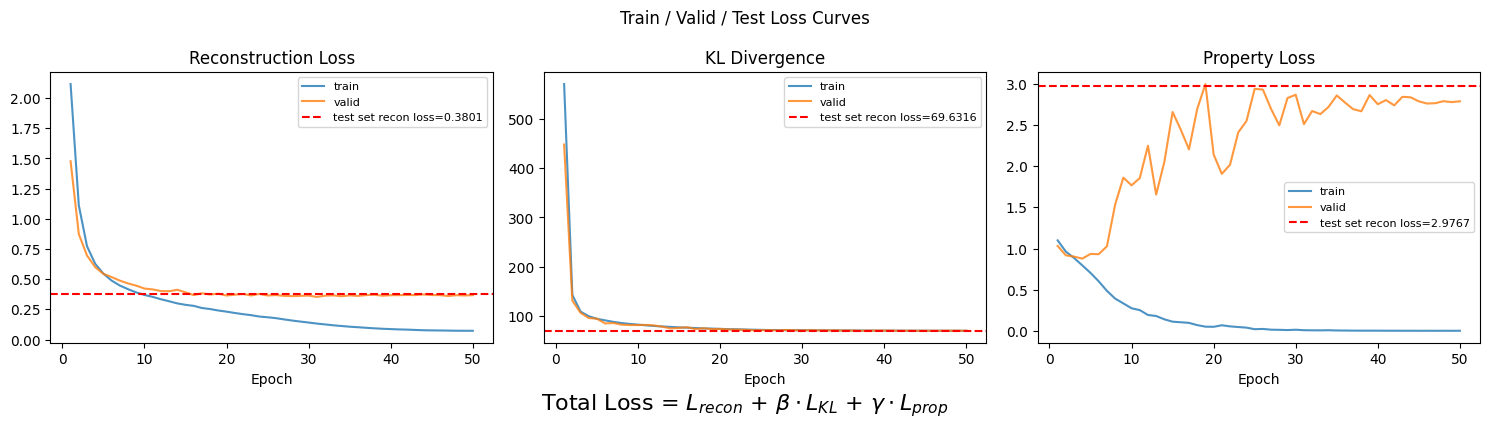

In [29]:
import mlflow
mlflow.set_tracking_uri("file:///Users/elenipsaromatis/Documents/mol-vae/notebooks/mlruns")
client = mlflow.tracking.MlflowClient()

def get_metric(run_id, metric_name):
    return [m.value for m in client.get_metric_history(run_id, metric_name)]

# compute test means
model.eval()
recon_losses, kl_losses, prop_losses = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits, mu, log_var, prop_logit = model(x)
        loss, recon, kl, prop = vae_loss(
            logits, x[:, 1:], mu, log_var,
            beta=BETA_MAX,
            prop_logit=prop_logit,
            labels=y.float(),
            gamma=GAMMA,
            kl_free_bits=KL_FREE_BITS
        )
        recon_losses.append(recon.item())
        kl_losses.append(kl.item())
        prop_losses.append(prop.item())

test_means = {
    'Reconstruction Loss': sum(recon_losses) / len(recon_losses),
    'KL Divergence':       sum(kl_losses)    / len(kl_losses),
    'Property Loss':       sum(prop_losses)  / len(prop_losses),
}

# pull train/valid curves from active run
run_id = "9b0acf7791b84aabad40423d1d59c3ef"
train_recon = get_metric(run_id, "recon_loss")
train_kl    = get_metric(run_id, "kl_loss")
train_prop  = get_metric(run_id, "train_prop")
valid_recon = get_metric(run_id, "valid_recon")
valid_kl    = get_metric(run_id, "valid_kl")
valid_prop  = get_metric(run_id, "valid_prop")
epochs = range(1, len(train_recon) + 1)

pairs = [
    (train_recon, valid_recon, 'Reconstruction Loss'),
    (train_kl,    valid_kl,    'KL Divergence'),
    (train_prop,  valid_prop,  'Property Loss'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (train_vals, valid_vals, title) in zip(axes, pairs):
    ax.plot(epochs, train_vals, label='train', alpha=0.8)
    ax.plot(epochs, valid_vals, label='valid', alpha=0.8)
    ax.axhline(test_means[title], color='red', linestyle='--',
               label=f'test set recon loss={test_means[title]:.4f}')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)

plt.suptitle('Train / Valid / Test Loss Curves')
plt.tight_layout()
fig.text(
    0.5, -0.02,
    r'Total Loss = $L_{recon}$ + $\beta \cdot L_{KL}$ + $\gamma \cdot L_{prop}$',
    ha='center', fontsize=16
)
plt.show()

# Latent Space Interpolation
To assess whether the latent space is structured, we interpolate between pairs of molecules from the test set. Each molecule is encoded to its mean latent vector mu using the trained encoder. We then compute intermediate vectors along the straight line connecting two latent points:

z_t = (1 - t) * z_A + t * z_B, for t in {0.0, 0.25, 0.5, 0.75, 1.0}

Each z_t is decoded autoregressively (without teacher forcing) to a SMILES string, and RDKit is used to check chemical validity.

In [30]:
def decode_autoregressive(model, z, char2idx, idx2char, max_length, device):
    model.eval()
    sos_token = char2idx['<sos>']
    eos_token = char2idx['<eos>']
    
    input_token = torch.tensor([[sos_token]], device=device)  # (1, 1)
    generated = []
    
    # initialise hidden state from z
    hidden = model.decoder.fc_z(z)
    hidden = hidden.view(-1, model.decoder.n_layers, model.decoder.hidden_dim).permute(1, 0, 2).contiguous()
    
    with torch.no_grad():
        for _ in range(max_length - 1):
            x_onehot = F.one_hot(input_token, num_classes=model.decoder.vocab_size).float()  # (1, 1, vocab_size)
            z_expanded = z.unsqueeze(1)                                                        # (1, 1, latent_dim)
            gru_input = torch.cat([x_onehot, z_expanded], dim=-1)                             # (1, 1, vocab_size + latent_dim)
            output, hidden = model.decoder.gru(gru_input, hidden)
            logit = model.decoder.fc_out(output)                                               # (1, 1, vocab_size)
            next_token = logit.argmax(dim=-1)                                                  # (1, 1)
            token_id = next_token.item()
            if token_id == eos_token:
                break
            generated.append(token_id)
            input_token = next_token
    
    smiles = ''.join([idx2char[i] for i in generated if idx2char[i] not in ['<sos>', '<pad>', '<eos>']])
    return smiles


# pick two molecules from test set
x_a = test_dataset[0][0].unsqueeze(0).to(device)
x_b = test_dataset[100][0].unsqueeze(0).to(device)

with torch.no_grad():
    z_a, _ = model.encoder(x_a)
    z_b, _ = model.encoder(x_b)

for t in [0.0, 0.25, 0.5, 0.75, 1.0]:
    z_t = (1 - t) * z_a + t * z_b
    smiles = decode_autoregressive(model, z_t, char2idx, idx2char, MAX_LENGTH, device)
    mol = Chem.MolFromSmiles(smiles)
    print(f"t={t:.2f}: {smiles} | valid: {mol is not None}")

t=0.00: O=C(c1cc(F)c2c(c1)N(CCC2)CCCCC2)CCN(CCO)CC1 | valid: False
t=0.25: O=C(c1cc(F)c2c(c1)N(CCCN1CCN(Cc3ccccc3)CC2)CC1 | valid: False
t=0.50: O=C(c1cc(-c2ccc(F)cc2)nc2c1c(CN1CCN(CCO)C3c2ncccn2C3)cc1 | valid: False
t=0.75: COc1ccc(-n2c(=O)c(-c3cccc(C#N)c3)nc3cnc(N4CCNCC4)nc32)cc1 | valid: True
t=1.00: COc1ccc(-n2c(=O)c(-c3cccs3)nc3cnc(N4CCN(C)CC4)nc32)cc1 | valid: True


In [31]:
pairs = [(0, 100), (5, 200), (10, 300), (50, 400), (15, 250), (80, 350), (20, 450), (3, 180), (60, 120), (90, 500)]
t_values = [0.0, 0.25, 0.5, 0.75, 1.0]

total_intermediate, valid_intermediate = 0, 0

for idx_a, idx_b in pairs:
    x_a = test_dataset[idx_a][0].unsqueeze(0).to(device)
    x_b = test_dataset[idx_b][0].unsqueeze(0).to(device)
    
    with torch.no_grad():
        z_a, _ = model.encoder(x_a)
        z_b, _ = model.encoder(x_b)
    
    print(f"\nPair ({idx_a}, {idx_b})")
    for t in t_values:
        z_t = (1 - t) * z_a + t * z_b
        smiles = decode_autoregressive(model, z_t, char2idx, idx2char, MAX_LENGTH, device)
        mol = Chem.MolFromSmiles(smiles)
        valid = mol is not None
        if t not in [0.0, 1.0]:
            total_intermediate += 1
            valid_intermediate += int(valid)
        print(f"  t={t:.2f}: {smiles} | valid: {valid}")

print(f"\nIntermediate validity (t=0.25, 0.5, 0.75): {valid_intermediate}/{total_intermediate} = {valid_intermediate/total_intermediate:.1%}")


Pair (0, 100)
  t=0.00: O=C(c1cc(F)c2c(c1)N(CCC2)CCCCC2)CCN(CCO)CC1 | valid: False
  t=0.25: O=C(c1cc(F)c2c(c1)N(CCCN1CCN(Cc3ccccc3)CC2)CC1 | valid: False
  t=0.50: O=C(c1cc(-c2ccc(F)cc2)nc2c1c(CN1CCN(CCO)C3c2ncccn2C3)cc1 | valid: False
  t=0.75: COc1ccc(-n2c(=O)c(-c3cccc(C#N)c3)nc3cnc(N4CCNCC4)nc32)cc1 | valid: True
  t=1.00: COc1ccc(-n2c(=O)c(-c3cccs3)nc3cnc(N4CCN(C)CC4)nc32)cc1 | valid: True

Pair (5, 200)
  t=0.00: Cc1cc2ccccc2c1C(c1ccncc1)N1CCN(C(=O)c2cccnc2)CC1 | valid: False
  t=0.25: Cc1ccc2c(c1)c1ccnc(NCCN2CCOCC2)n1 | valid: False
  t=0.50: Cc1ccc(Sc2nc3c(c2C#N)CCCN3CCCC2)cc1 | valid: False
  t=0.75: Cc1ccc(Nc2nc(N3CCOCC3)nc(N3CCCCC3)n2)cc1 | valid: True
  t=1.00: c1ccc(NC(=S)N2CCC3(CC2)CCCC2)cc1 | valid: False

Pair (10, 300)
  t=0.00: Cn1c(=O)c2[nH]c(CCCc3ccc4[nH]c(=O)n(C)c(=O)n4C)n2)nc(C)c12 | valid: False
  t=0.25: Cn1c(=O)c2[nH]c(CCCc3ccc4c(c3)OCO4)nc2n(C)c1=O | valid: True
  t=0.50: Cn1c(=O)c2c(nc(C)c2-c2ccc(N3CCOCC3)nc2n(C)c1=O | valid: False
  t=0.75: CN1C(=O)C(CC(=O)

# PCA and UMAP

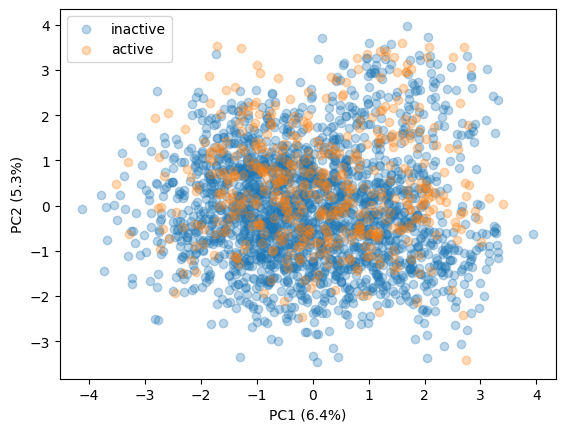

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

model.eval()
mus, all_labels = [], []
with torch.no_grad():
    for batch, labels in test_loader:
        batch = batch.to(device)
        mu, _ = model.encoder(batch)
        mus.append(mu.cpu())
        all_labels.append(labels)

mus = torch.cat(mus).numpy()
all_labels = torch.cat(all_labels).numpy()

pca = PCA(n_components=2)
z = pca.fit_transform(mus)

plt.scatter(z[all_labels==0, 0], z[all_labels==0, 1], alpha=0.3, label='inactive')
plt.scatter(z[all_labels==1, 0], z[all_labels==1, 1], alpha=0.3, label='active')
plt.legend()
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.show()

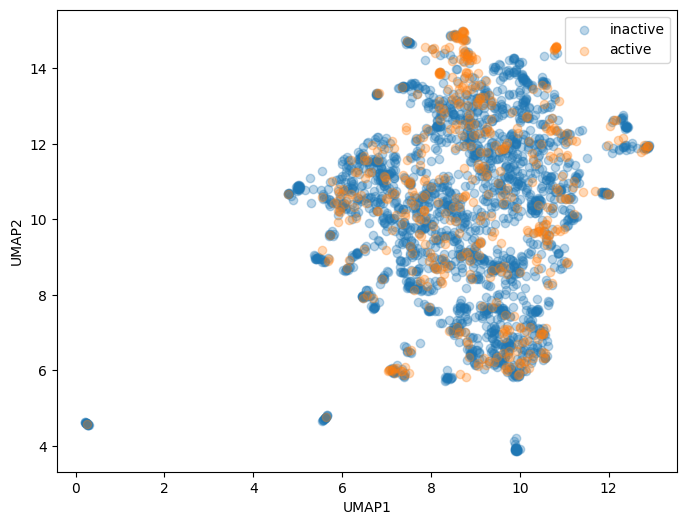

In [33]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, random_state=42)
z = reducer.fit_transform(mus)

plt.figure(figsize=(8, 6))
plt.scatter(z[all_labels==0, 0], z[all_labels==0, 1], alpha=0.3, label='inactive')
plt.scatter(z[all_labels==1, 0], z[all_labels==1, 1], alpha=0.3, label='active')
plt.legend()
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()